Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

Load Dataset

In [ ]:
df = pd.read_csv("/content/sample_data/mnist_train_small.csv",header=None, nrows=30000)

Sentiment Distribution

Purpose: Understand class balance

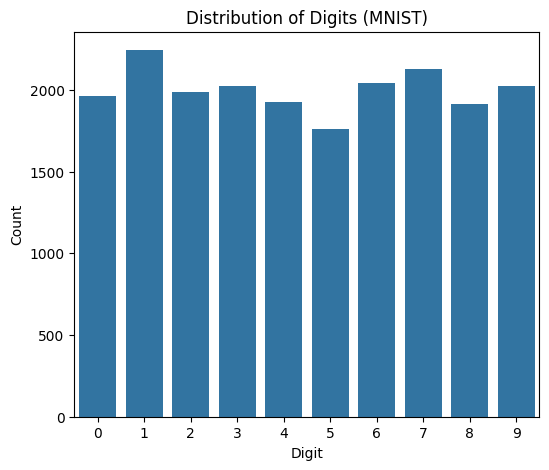

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x=df[0])

plt.title("Distribution of Digits (MNIST)")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

Sample Images

Purpose: Visualize a few digit images from the dataset.

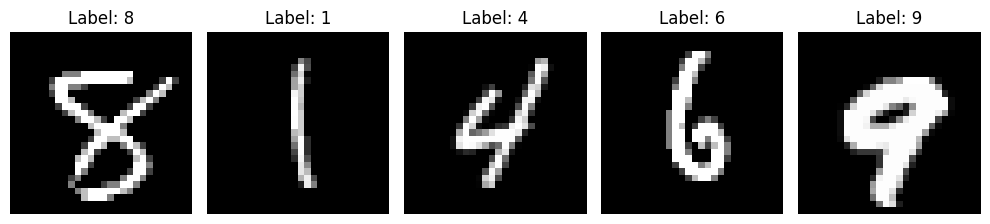

In [ ]:
import numpy as np

num_samples = 5
sample_indices = np.random.choice(len(df), num_samples, replace=False)

plt.figure(figsize=(10, 4))
for i, index in enumerate(sample_indices):
    image_data = df.iloc[index, 1:].values
    label = df.iloc[index, 0]

    image = image_data.reshape(28, 28)

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Digit Distribution Pie Chart

Purpose: Visualize the proportional distribution of each digit label.

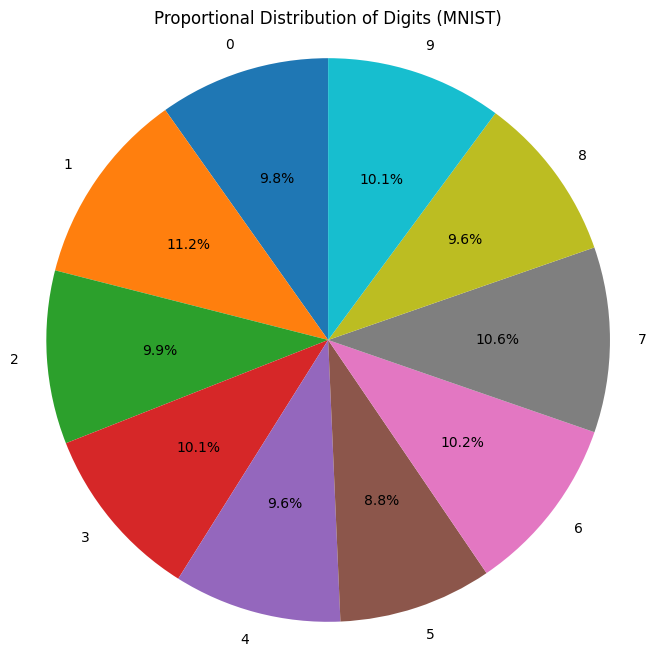

In [ ]:
digit_counts = df[0].value_counts().sort_index()

plt.figure(figsize=(8, 8))
plt.pie(digit_counts, labels=digit_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proportional Distribution of Digits (MNIST)')
plt.axis('equal')
plt.show()

Dimensionality Reduction and Scatter Plot

Purpose: Visualize the MNIST digits in a 2D space using PCA to observe potential clustering.

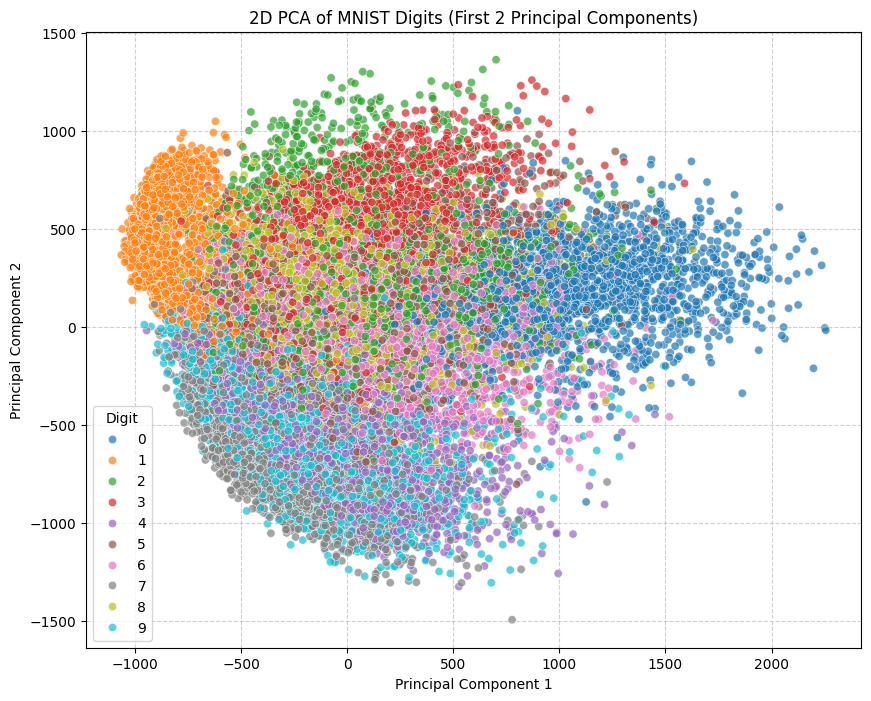

In [ ]:
from sklearn.decomposition import PCA

# Separate features (pixel data) from labels
X = df.iloc[:, 1:]  # All columns except the first one (label)
y = df.iloc[:, 0]   # The first column is the label

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Digit'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Digit',
    palette='tab10',
    data=pca_df,
    legend='full',
    alpha=0.7
)
plt.title('2D PCA of MNIST Digits (First 2 Principal Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Histograms of Pixel Intensities

Purpose: Understand the distribution of pixel values in the dataset.

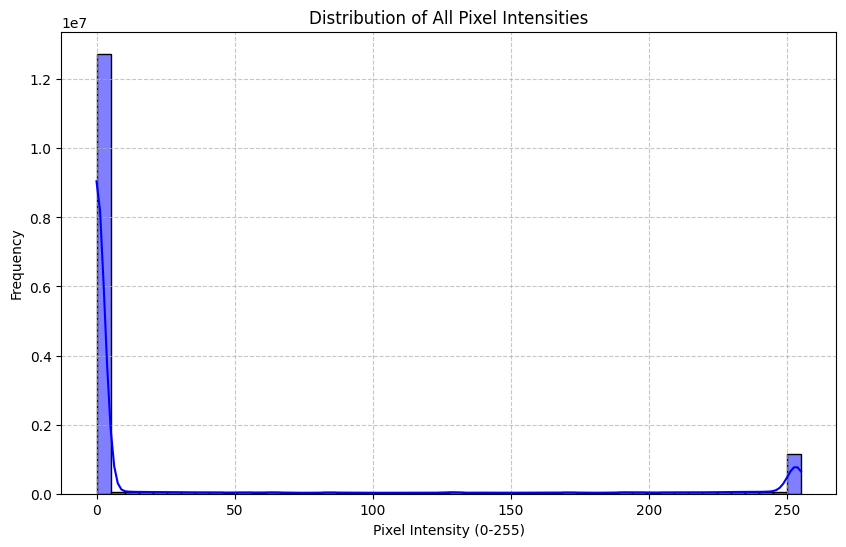

In [ ]:
all_pixel_values = X.values.flatten()

plt.figure(figsize=(10, 6))
sns.histplot(all_pixel_values, bins=50, kde=True, color='blue')
plt.title('Distribution of All Pixel Intensities')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The distribution of pixel intensities for each digit, focusing on the non-zero pixels to understand the 'ink' distribution.

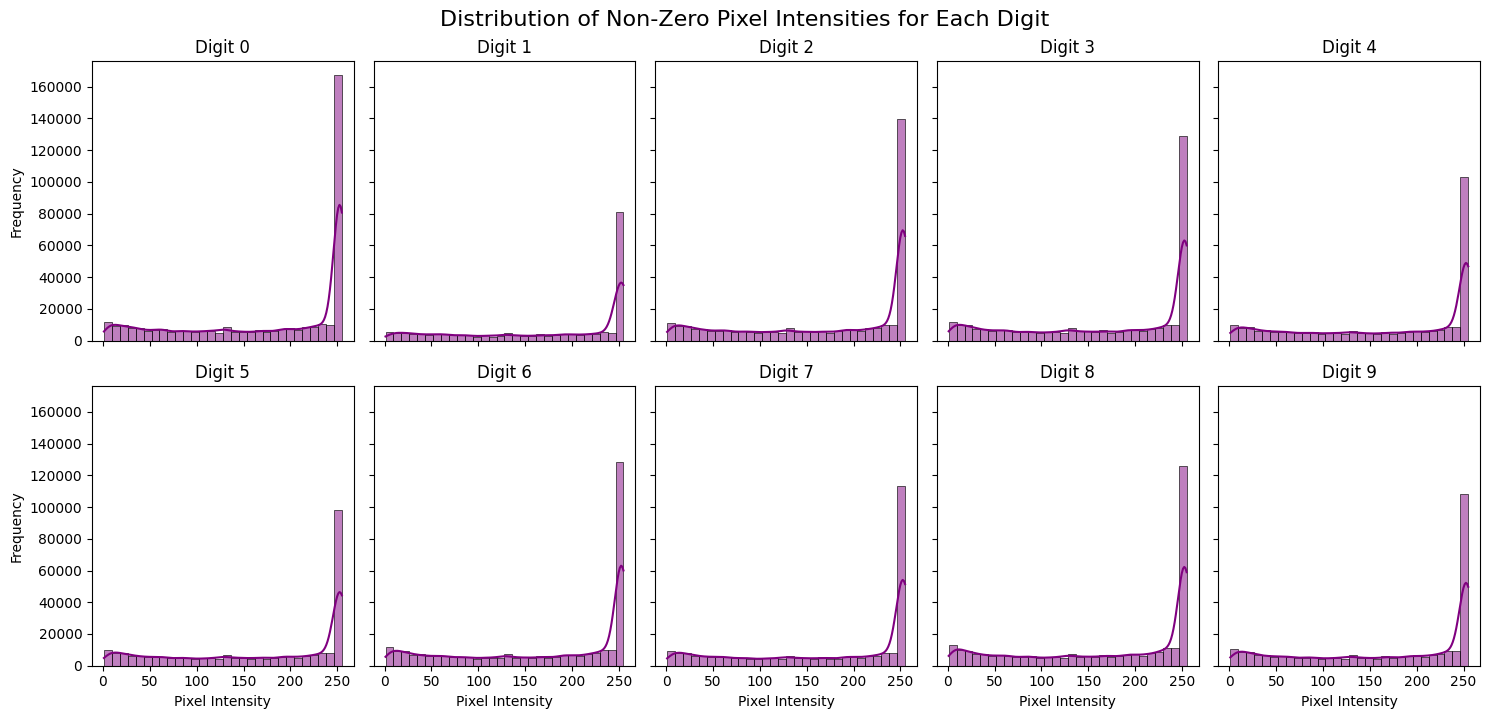

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 7), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(10):
    digit_pixels = X[y == i].values.flatten()

    digit_pixels_nonzero = digit_pixels[digit_pixels > 0]

    sns.histplot(digit_pixels_nonzero, bins=30, kde=True, ax=axes[i], color='purple')
    axes[i].set_title(f'Digit {i}')
    axes[i].set_xlabel('Pixel Intensity')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Distribution of Non-Zero Pixel Intensities for Each Digit', y=1.02, fontsize=16)
plt.show()

Box Plot of Non-Zero Pixel Intensities by Digit

Purpose: Visualize the distribution (median, quartiles, outliers) of pixel intensities for each digit, focusing on the 'ink' pixels.

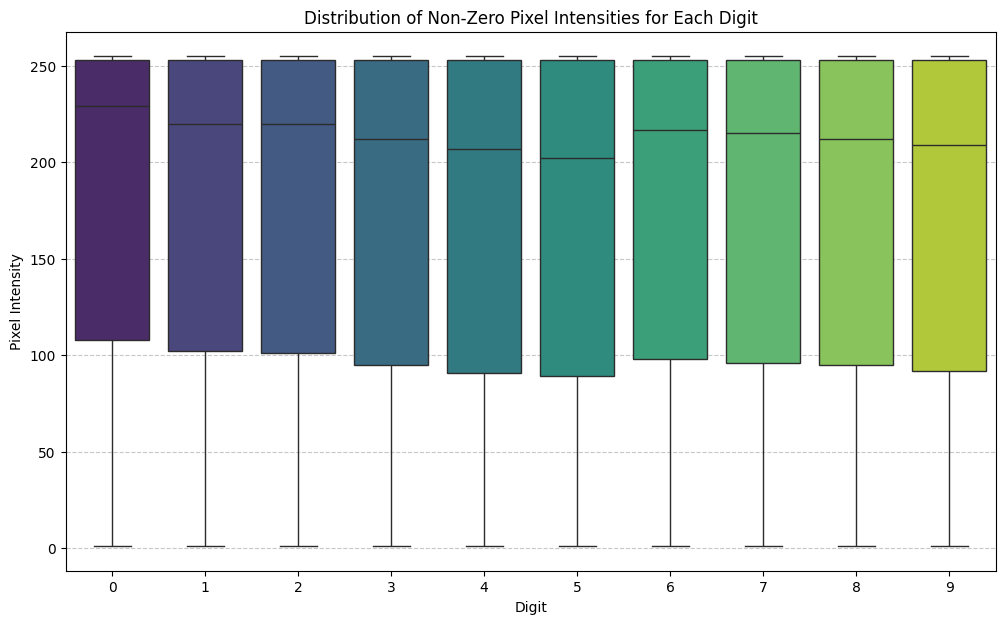

In [ ]:
import numpy as np

pixel_intensity_data = []
for i in range(10):
    digit_pixels = X[y == i].values.flatten()
    pixel_intensity_data.append(digit_pixels[digit_pixels > 0])

plt.figure(figsize=(12, 7))
sns.boxplot(data=pixel_intensity_data, palette='viridis')
plt.title('Distribution of Non-Zero Pixel Intensities for Each Digit')
plt.xlabel('Digit')
plt.ylabel('Pixel Intensity')
plt.xticks(ticks=range(10), labels=range(10))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()